# CLIP (Contrastive Language-Image Pre-Training)


* (clip paper)[https://arxiv.org/abs/2103.00020]

* (clip code)[https://github.com/openai/CLIP/blob/main/clip/model.py]

* (clip in transformers)[https://github.com/huggingface/transformers/tree/main/src/transformers/models/clip]


## SigLIP (Sigmoid Loss for Language–Image Pre-training)

* ( siglip paper)[https://arxiv.org/abs/2303.15343]


### Intuition

* This is a **dual encoder** model. It is trained with **contrastive learning** to align the embedding pairs of text and images. 
* There is no decoder and no generation so this isnt a generative model nor a multimodal LLM yet. 

### Architecture

1. Image Encoder: this is a ViT. We can literally take what we built in module 1 and import it. Its task is to take an image and output its embedding vector. 
2. Text Encoder: this is a transformer with a causal mask. We can import from what we built in our text encoder notebook. Its task is to take a sentence and output its embedding vector. 
3. Contrastive loss: this will our training objective. The idea is to make a matrix of a bunch of pairs of captions and images, get their embeddings, and make the diagonal high in cosine similarity and the others far away in cosine similarity.

* we will need both encoders to have the same `hidden_dim` so we can get the cosine similarity of pairs and we will need some normalization for their repsective outputs. 

### Training

* given a batch of B image-text pairs:
* encode all images `[N, 512]`
* encode all text descriptions of the images `[N, 512]`
* compute an `NxN` similarity matrix which will be `logits = image_embeddings @ text_embeddings.T * temperature`
* diagonal of `NxN` similarity matrix is correct pairs
* calculate **cross-entropy loss** along the rows and the columns. 

### Imports

We can import our vanilla ViT from ../module1_vision_transformer_foundations/vit.py and our text encoder from text_encoder.py

In [1]:
from text_encoder import TextEncoder

In [7]:
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
sys.path.append('../module1_vision_transformer_foundations')
from vit import PatchEmbedding, TransformerEncoder

In [8]:
class VisionEncoder(nn.Module):
    def __init__(self, img_size, patch_size, num_hiddens, num_heads, num_classes, depth=6, dropout=0.1):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_embedding = PatchEmbedding(img_size, patch_size, num_hiddens)
        self.cls_token = nn.Parameter(torch.randn(1, 1, num_hiddens))
        self.pos_embedding = nn.Parameter(torch.randn(1, self.num_patches + 1, num_hiddens))
        self.encoder = TransformerEncoder(num_hiddens, depth, num_heads, mlp_dim=num_hiddens * 4)

    def forward(self, x):
        batch = x.shape[0]
        patches = self.patch_embedding(x)
        patches = patches.flatten(2).transpose(1, 2)
        cls_tokens = self.cls_token.expand(batch, -1, -1)
        x = torch.cat((cls_tokens, patches), dim=1)
        x = x + self.pos_embedding
        x = self.encoder(x)
        return x

## Putting it all together


* now its just as simple as geting our vision encoder, the text encoder, projecting them to be the same dimensions, generating a similarity matrix with normalized scores, getting cross entropy across rows and columns and contrast loss that. 

In [125]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class CLIP(nn.Module):
    def __init__(self, vision_encoder, text_encoder, vision_encoder_dim, text_encoder_dim, temperature):
        super().__init__()
        self.vision_encoder = vision_encoder
        self.text_encoder = text_encoder
        self.vision_projection = nn.Linear(vision_encoder_dim, text_encoder_dim)
        self.temperature = temperature
        # self.contrast

    def forward(self, pair):
        x_vision = self.vision_encoder(pair[0])
        cls_emb_vision = x_vision[:, 0]
        image_embs = self.vision_projection(cls_emb_vision)
        text_embs = self.text_encoder(pair[1])
        image_embs = image_embs / image_embs.norm(dim=-1, keepdim=True) # without this, the mean and std of the two are very different!                                                                                              
        text_embs = text_embs / text_embs.norm(dim=-1, keepdim=True)    
        logits = (image_embs @ text_embs.T) * self.temperature  
        labels = torch.arange(logits.shape[0], device=logits.device)   
        loss_i = F.cross_entropy(logits, labels)       # rows: for each image, which text?                                                                            
        loss_t = F.cross_entropy(logits.T, labels)     # cols: for each text, which image?                                                                            
        loss = (loss_i + loss_t) / 2 
        return logits, loss

In [126]:
vision_encoder = VisionEncoder(img_size=56, patch_size=7, num_hiddens=768,num_heads=8, num_classes=100, depth=2, dropout=0.1)
# lets input a tokenizer that has been already trained
from transformers import CLIPTokenizer 
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
text_encoder = TextEncoder( vocab_size=49408, embed_dim=512, num_heads=8, num_layers=12, max_seq_len=77, projection_dim=512)

In [127]:
clip = CLIP(vision_encoder, text_encoder, 768, 512, temperature = 0.1)

In [128]:
img = torch.randn(4, 3, 56, 56)
text_input = ["This is the pitcure of a cow in a pasture. The cow is very close to the camera and its a sunny day.",
              "This is a dog",
              "This is a cat",
              "This is an airplane about to take off"]
batch = tokenizer(text_input, padding=True, max_length=77, truncation=True, return_tensors="pt")                                                                                           

In [129]:
pair = (img, batch["input_ids"])

In [132]:
logits, loss = clip(pair)

In [133]:
logits.shape, loss

(torch.Size([4, 4]), tensor(1.3864, grad_fn=<DivBackward0>))

In [134]:
from torchvision import datasets, transforms                                                                                                                  
                                                                                                                                                                
transform = transforms.Compose([                                                                                                                              
    transforms.Resize((56, 56)),                                                                                                                            
    transforms.ToTensor(),                                                                                                                                    
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])                                                                                                                                                            
                  
dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)    

100%|██████████| 170M/170M [00:35<00:00, 4.83MB/s] 


In [135]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
clip = clip.to(device)

In [138]:
from torch.utils.data import DataLoader
optimizer = torch.optim.AdamW(clip.parameters(), lr=1e-4, weight_decay=0.01)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=2)
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                     'dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:
num_epochs = 50

for epoch in range(num_epochs):
    clip.train()
    total_loss = 0
    num_batches = 0

    for images, labels in dataloader:
        # Build captions from labels
        captions = [f"a photo of a {cifar10_classes[l]}" for l in labels]
        tokens = tokenizer(captions, padding=True, max_length=77,
                        truncation=True, return_tensors="pt")

        images = images.to(device)
        token_ids = tokens["input_ids"].to(device)

        logits, loss = clip((images, token_ids))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    avg_loss = total_loss / num_batches
    print(f"Epoch {epoch+1}/{num_epochs} — loss: {avg_loss:.4f}")

Epoch 1/50 — loss: 4.7943
Epoch 2/50 — loss: 4.7944
Epoch 3/50 — loss: 4.7941
Epoch 4/50 — loss: 4.7952
Epoch 5/50 — loss: 4.7937
Epoch 6/50 — loss: 4.7946
Epoch 7/50 — loss: 4.7944
Epoch 8/50 — loss: 4.7929
Epoch 9/50 — loss: 4.7983


In [140]:
clip.eval()

# Encode all class prompts once
class_prompts = [f"a photo of a {c}" for c in cifar10_classes]
class_tokens = tokenizer(class_prompts, padding=True, max_length=77,
                        truncation=True, return_tensors="pt")["input_ids"].to(device)

with torch.no_grad():
    text_embs = clip.text_encoder(class_tokens)
    text_embs = text_embs / text_embs.norm(dim=-1, keepdim=True)  # (10, 512)

# Test on a batch
test_dataset = datasets.CIFAR10(root='./data', train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [141]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        x = clip.vision_encoder(images)
        image_embs = clip.vision_projection(x[:, 0])
        image_embs = image_embs / image_embs.norm(dim=-1, keepdim=True)

        # Each image vs all 10 class prompts
        sims = image_embs @ text_embs.T  # (B, 10)
        preds = sims.argmax(dim=-1)

        correct += (preds == labels.to(device)).sum().item()
        total += labels.shape[0]

print(f"accuracy: {correct/total:.2%}")

Zero-shot accuracy: 18.46%


In [ ]:
import matplotlib.pyplot as plt

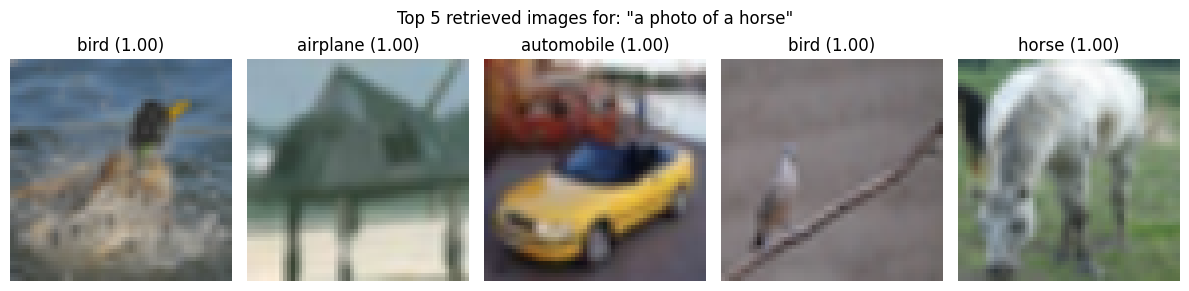

In [143]:
# Encode a bunch of test images
all_image_embs = []
all_labels = []
retrieval_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

with torch.no_grad():
    for images, labels in retrieval_loader:
        x = clip.vision_encoder(images.to(device))
        embs = clip.vision_projection(x[:, 0])
        embs = embs / embs.norm(dim=-1, keepdim=True)
        all_image_embs.append(embs.cpu())
        all_labels.append(labels)

all_image_embs = torch.cat(all_image_embs)
all_labels = torch.cat(all_labels)

# Query with a text prompt
query = "a photo of a horse"
query_tokens = tokenizer([query], padding=True, max_length=77,
                        truncation=True, return_tensors="pt")["input_ids"].to(device)
with torch.no_grad():
    query_emb = clip.text_encoder(query_tokens)
    query_emb = query_emb / query_emb.norm(dim=-1, keepdim=True)

sims = (all_image_embs @ query_emb.cpu().T).squeeze()
top5 = sims.topk(5).indices

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
fig.suptitle(f'Top 5 retrieved images for: "{query}"')
for i, idx in enumerate(top5):
    img = test_dataset[idx][0] * 0.5 + 0.5  # undo normalization
    axes[i].imshow(img.permute(1, 2, 0).clamp(0, 1))
    axes[i].set_title(f"{cifar10_classes[all_labels[idx]]} ({sims[idx]:.2f})")
    axes[i].axis('off')
plt.tight_layout()
plt.show()    